In [8]:
# %%
import matplotlib.pyplot as plt
import gc
import os
import shutil
import sys
import time
import warnings
from functools import partial
import torch.distributed as tdist
import torch
from PIL import Image
from torch.utils.data import DataLoader
from utils.dynamic_resolution import dynamic_resolution_h_w, h_div_w_templates
import numpy as np
import dist
from utils import arg_util, misc
from utils.data import build_dataset
from utils.data_sampler import DistInfiniteBatchSampler, EvalDistributedSampler
from utils.misc import auto_resume
import math
from models import SRVAR, VQVAE, build_vae_srvar

args: arg_util.Args = arg_util.Args()
# args.data = "./data/df2k_ost/GT_resized"
# args.data = "./data/DIV2K_train_HR"
# args.data = "./data/train"
# args.data = "./data/brats_256_t1_new/train"
args.batch_size = 1
args.fp16=1
args.alng = 1e-3
args.wpe = 0.1
args.pn = "1M"
args.rope2d_normalized_by_hw = 2
args.rope2d_each_sa_layer = 1
args.enable_checkpointing = "full-block"
args.tlen = 1024
args.device = "cuda"

args.Ct5 = 64
args.vocab_size = 4096
args.data_path = "./data/brats_256_t1_pair/"
tot = 10
ckpt_path_srvar = f"local_output/ar-ckpt-last.pth"

args.seed = 666
args.seed_everything(False)

In [3]:

V=args.vocab_size
Cvae=args.Ct5
ch=160
share_quant_resi=4
patch_nums=(1, 2, 3, 4, 5, 6, 8, 10, 13, 16)   # 10 steps by default

# print(torch.load(ckpt_path, map_location='cpu')['trainer'].keys())
vae = VQVAE(vocab_size=V, z_channels=Cvae, ch=ch, test_mode=True, share_quant_resi=share_quant_resi, v_patch_nums=patch_nums).to(args.device)
    
srvar_kw = dict(
    low_channel=args.Ct5, low_len=args.tlen,
    norm_eps=args.norm_eps, rms_norm=args.rms,
    shared_aln=args.saln, head_aln=args.haln,
    cond_drop_rate=args.cfg, rand_uncond=args.rand_uncond, drop_rate=args.drop,
    cross_attn_layer_scale=args.ca_gamma, nm0=args.nm0, tau=args.tau, cos_attn=args.cos, swiglu=args.swi,
    raw_scale_schedule=patch_nums,
    head_depth=args.dec,
    top_p=args.tp, top_k=args.tk,
    customized_flash_attn=args.flash, fused_mlp=args.fuse, fused_norm=args.fused_norm,
    checkpointing=args.enable_checkpointing,
    pad_to_multiplier=args.pad_to_multiplier,
    use_flex_attn=args.use_flex_attn,
    batch_size=args.batch_size,
    add_lvl_embeding_only_first_block=args.add_lvl_embeding_only_first_block,
    rope2d_each_sa_layer=args.rope2d_each_sa_layer,
    rope2d_normalized_by_hw=args.rope2d_normalized_by_hw,
    pn=args.pn,
    train_h_div_w_list=None,
    always_training_scales=args.always_training_scales,
    apply_spatial_patchify=args.apply_spatial_patchify,
    block_chunks = args.block_chunks,

)
if args.dp >= 0: srvar_kw['drop_path_rate'] = args.dp
if args.hd > 0: srvar_kw['num_heads'] = args.hd

# print(f'[create srvar] constructor kw={srvar_kw}\n')

vae.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['vae_local'])

srvar_kw['vae_local'] = vae


srvar: SRVAR = SRVAR(**srvar_kw)
srvar = srvar.to(args.device)
srvar.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['srvar_wo_ddp'])

srvar.eval()
vae.eval()


/tmp/ipykernel_1019534/1281521595.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['vae_lo

self.codebook_dim: 64, self.add_lvl_embeding_only_first_block: 1,             self.rope2d_each_sa_layer: 1, self.rope2d_normalized_by_hw: 2
TextAttentivePool: Ct5=64, D=1024, head_dim=8
self.num_blocks_in_a_chunk=4, depth=16, block_chunks=4

[constructor]  ==== customized_flash_attn=False (using_flash=0/16), fused_mlp=False (fused_mlp=0/16) ==== 
    [Infinity config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0, swiglu=False num_blocks_in_a_chunk=4
    [drop ratios] drop_rate=0.0, drop_path_rate=0 (tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))



/tmp/ipykernel_1019534/1281521595.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  srvar.load_state_dict(torch.load(ckpt_path_srvar, map_location='cpu')['trainer']['srva

VQVAE(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0-1): 2 x Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 160, eps=1e-06, affine=True)
            (conv1): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 160, eps=1e-06, affine=True)
            (dropout): Identity()
            (conv2): Conv2d(160, 160, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nin_shortcut): Identity()
          )
        )
        (attn): ModuleList()
        (downsample): Downsample2x(
          (conv): Conv2d(160, 160, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (2): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 160, eps=1e-06, affine=True)
            (conv1): Conv2d(160, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1,

In [4]:
dataset_train, dataset_val = build_dataset(
    args.data_path, hflip=args.hflip, 
)
types = str((type(dataset_train).__name__, type(dataset_val).__name__))

ld_val = DataLoader(
    dataset_val, num_workers=args.workers, batch_size=args.batch_size,shuffle=False,
)
del dataset_val

ld_train = DataLoader(
    dataset=dataset_train, num_workers=args.workers,batch_size=args.batch_size,shuffle=False,
)


[Dataset] len(train_set)=20654, len(val_set)=4475
Transform [train] = 
ToTensor()
<function normalize_01_into_pm1 at 0x7174295e95e0>
---------------------------

Transform [val] = 
ToTensor()
<function normalize_01_into_pm1 at 0x7174295e95e0>
---------------------------



In [5]:
def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12115'
    tdist.init_process_group("nccl", rank=rank, world_size=world_size)
setup(0,1)

/home/china/Neesky/VAR/models/basic.py:504: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):    # disable half precision


test 0: tensor([2585, 2029, 2076, 3614, 3908,  613, 2738, 3902, 3875, 2924, 2518, 1025,
        2277, 4088, 2947, 3760, 3672,  979, 4030, 3821, 2450, 2637,  136, 3722,
         326, 1179, 2912, 1787, 1394, 1455], device='cuda:0')
train0: tensor([2585, 2029, 2076, 3614, 3908,  613, 2738, 3902, 3875, 2924, 2518, 1025,
        2277, 4088, 2947, 3760, 3672,  979, 4030, 3821, 2450, 2637,  136, 3722,
         326, 1179, 2912, 1787, 1394, 1455], device='cuda:0')
gt   0: tensor([2585, 2029, 2076, 3614, 3908,  613, 2738, 3902, 3875, 2924, 2518, 1025,
        2277, 4088, 2947, 3760, 3672,  979, 4030, 3821, 2450, 2637,  136, 3722,
         326, 1179, 2912, 1787, 1394, 1455], device='cuda:0')
acc_train: 0.875
acc_list: 0.763235294117647
train_list: 0.7764705882352941


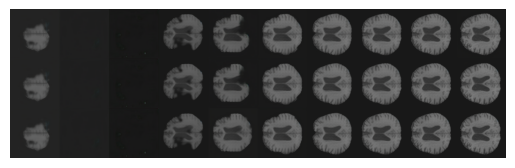

test 1: tensor([2585, 2029, 3928, 3812, 1678,  613, 2328, 1972, 3109, 2924, 2518, 1437,
        1634, 4088, 2862, 1171, 1275, 2475, 1358, 1953, 1270, 3084, 1823, 4018,
        3756, 3012, 2912,  994, 2621, 3098], device='cuda:0')
train1: tensor([2585, 2029, 3928, 3812, 1678,  613, 2328, 1972, 3109, 2924, 2518, 1437,
        1634, 4088, 2862, 1171, 1275, 2475, 1358, 1953, 1270, 3084, 1823, 4018,
        3756, 3012, 2912,  994, 2621, 3098], device='cuda:0')
gt   1: tensor([2585, 2029, 3928, 3812, 1678,  613, 2328, 1972, 3109, 2924, 2518, 1437,
        1634, 4088, 2862, 1171, 1275, 2475, 1358, 1953, 1270, 3084, 1823, 4018,
        3756, 3012, 2912,  994, 2621, 3098], device='cuda:0')
acc_train: 0.9926470588235294
acc_list: 0.9191176470588235
train_list: 0.9235294117647059


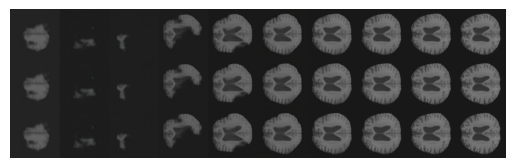

test 2: tensor([2585, 3821, 3928, 3426, 3283, 1973, 2483, 2589, 1482,   48, 1275, 1437,
        3252,  799,  749, 1480,  388, 3030, 1220, 2251, 2727, 1105, 2573,  694,
        1533, 3965, 2510, 3110, 3250, 3869], device='cuda:0')
train2: tensor([2585, 3821, 3928, 3426, 3283, 1973, 2738, 1972, 3109, 2929, 1564, 1437,
        1541, 3928,   17, 2015, 1616, 2475, 1358, 1157,   94, 3396, 2573, 3590,
         675, 1277,  119,  994, 1437,  667], device='cuda:0')
gt   2: tensor([2585, 3821, 3928, 3426, 1678, 1973, 2738, 1972, 3109, 2929, 1564, 1437,
        1541, 3928,   17, 2015, 1616, 2475, 1358, 1157,   94, 3396, 2573, 3590,
         675, 1277,  119,  994, 1437,  667], device='cuda:0')
acc_train: 0.9882352941176471
acc_list: 0.010294117647058823
train_list: 0.011764705882352941


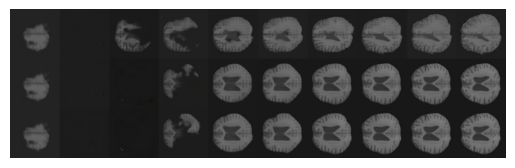

test 3: tensor([2585, 3821, 3928,  665, 1678,  613, 1605, 2828, 3771, 2929, 2518, 1191,
         471, 3928, 3514,  375, 1918,  320, 2898,  370, 3601, 3396,  131,  349,
         312, 3773,  613, 1037, 4029, 1478], device='cuda:0')
train3: tensor([2585, 3821, 3928,  665, 1678,  613, 1605, 2828, 3771, 2929, 2518, 1191,
         471, 3928, 3514,  375, 1918,  320, 2898,  370, 3601, 3396,  131,  349,
         312, 3773,  613, 1037, 4029, 1478], device='cuda:0')
gt   3: tensor([2585, 3821, 3928,  665, 1678,  613, 1605, 2828, 3771, 2929, 2518, 1191,
         471, 3928, 3514,  375, 1918,  320, 2898,  370, 3601, 3396,  131,  349,
         312, 3773,  613, 1037, 4029, 1478], device='cuda:0')
acc_train: 0.9941176470588236
acc_list: 0.9926470588235294
train_list: 0.9985294117647059


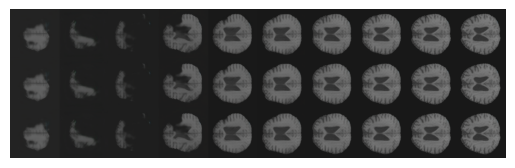

test 4: tensor([2585, 3821, 3928,  665, 1678,  613, 2874, 1616, 2277, 2929,  326, 2316,
        1437,  156, 3514, 1162,  115, 2612, 1358, 3475, 3601,  511,  163, 4037,
         326, 3194, 2471,  421, 1394, 2465], device='cuda:0')
train4: tensor([2585, 3821, 3928,  665, 1678,  613, 2874, 1616, 2277, 2929,  326, 2316,
        1437,  156, 3514, 1162,  115, 2612, 1358, 3475, 3601,  511,  163, 4037,
         326, 3194, 2471,  421, 1394, 2465], device='cuda:0')
gt   4: tensor([2585, 3821, 3928,  665, 1678,  613, 2874, 1616, 2277, 2929,  326, 2316,
        1437,  156, 3514, 1162,  115, 2612, 1358, 3475, 3601,  511,  163, 4037,
         326, 3194, 2471,  421, 1394, 2465], device='cuda:0')
acc_train: 0.9985294117647059
acc_list: 0.9955882352941177
train_list: 0.9970588235294118


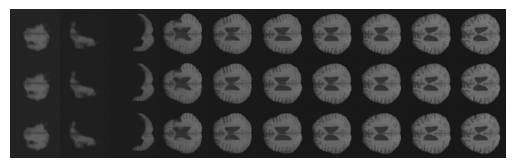

test 5: tensor([2585, 1634, 3928, 3812, 1678, 3497,  763, 1643, 3377,  818,  326, 3908,
        4037, 4032, 2623,  646,  820, 3879,  458, 3475, 2655,  511,  142, 1480,
        2218,  751, 2492, 1875, 3060, 3875], device='cuda:0')
train5: tensor([2585, 1634, 3928, 3812, 1678, 3497,  763, 1643, 3377,  818,  326, 3908,
        4037, 4032, 2623,  646,  820, 3879,  458, 3475, 2655,  511,  142, 1480,
        2218,  751, 2492, 1875, 3060, 3875], device='cuda:0')
gt   5: tensor([2585, 1634, 3928, 3812, 1678, 3497,  763, 1643, 3377,  818,  326, 3908,
        4037, 4032, 2623,  646,  820, 3879,  458, 3475, 2655,  511,  142, 1480,
        2218,  751, 2492, 1875, 3060, 3875], device='cuda:0')
acc_train: 0.9794117647058823
acc_list: 0.9573529411764706
train_list: 0.9705882352941176


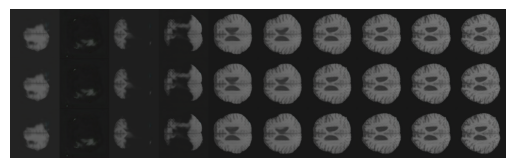

test 6: tensor([2585,   39, 3928, 3812, 1678, 2142, 2356, 2546,  665, 3252,  326, 3908,
        1437, 1416,  374, 2258, 4035, 2912, 2765, 2634, 1370, 3902,  142, 4000,
        2218,  843, 3066, 2580,  314,   85], device='cuda:0')
train6: tensor([2585,   39, 3928, 3812, 1678, 2142, 2356, 2546,  665, 3252,  326, 3908,
        1437, 1416,  374, 2258, 4035, 2912, 2765, 2634, 1370, 3902,  142, 4000,
        2218,  843, 3066, 2580,  314,   85], device='cuda:0')
gt   6: tensor([2585,   39, 3928, 3812, 1678, 2142, 2356, 2546,  665, 3252,  326, 3908,
        1437, 1416,  374, 2258, 4035, 2912, 2765, 2634, 1370, 3902,  142, 4000,
        2218,  843, 3066, 2580,  314,   85], device='cuda:0')
acc_train: 0.986764705882353
acc_list: 0.9794117647058823
train_list: 0.986764705882353


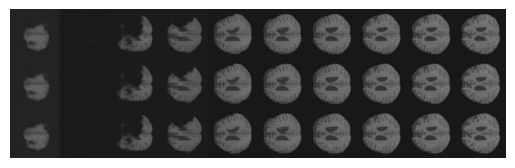

test 7: tensor([2585,  315, 2546, 3812, 1678, 3563, 2124, 2589,  665, 4000, 1616, 1285,
        1437, 1416,  770, 3759, 1918, 2164, 1760,  349,  654, 2628, 1694,  330,
        2218, 1162,  132,  617,  962,  281], device='cuda:0')
train7: tensor([2585,  315, 2546, 3812, 1678, 3563, 2124, 2589,  665, 4000, 1616, 1285,
        1437, 1416,  770, 3759, 1918, 2164, 1760,  349,  654, 2628, 1694,  330,
        2218, 1162,  132,  617,  962,  281], device='cuda:0')
gt   7: tensor([2585,  315, 2546, 3812, 1678, 3563, 2124, 2589,  665, 4000, 1616, 1285,
        1437, 1416,  770, 3759, 1918, 2164, 1760,  349,  654, 2628, 1694,  330,
        2218, 1162,  132,  617,  962,  281], device='cuda:0')
acc_train: 0.9647058823529412
acc_list: 0.961764705882353
train_list: 0.9720588235294118


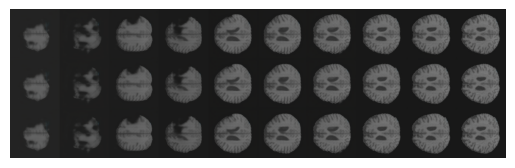

test 8: tensor([2585,  315, 2076, 3812, 1678, 3335, 1416, 1751,  665, 4000, 2546, 3821,
        1784, 1723, 1275, 3667,  611, 3058, 3068,  511,  654, 2628, 2372,  536,
        2202, 2933, 1714, 1875, 1383, 1221], device='cuda:0')
train8: tensor([2585,  315, 2076, 3812, 1678, 3335, 1416, 1751,  665, 4000, 2546, 3821,
        1784, 1723, 1275, 3667,  611, 3058, 3068,  511,  654, 2628, 2372,  536,
        2202, 2933, 1714, 1875, 1383, 1221], device='cuda:0')
gt   8: tensor([2585,  315, 2076, 3812, 1678, 3335, 1416, 1751,  665, 4000, 2546, 3821,
        1784, 1723, 1275, 3667,  611, 3058, 3068,  511,  654, 2628, 2372,  536,
        2202, 2933, 1714, 1875, 1383, 1221], device='cuda:0')
acc_train: 0.9808823529411764
acc_list: 0.9764705882352941
train_list: 0.9897058823529412


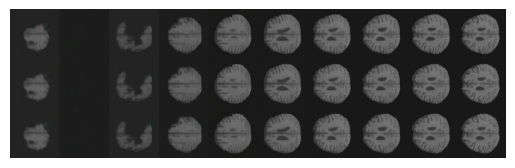

test 9: tensor([2585, 3283, 3928, 3812, 1678, 3562, 1355, 4032,   78, 1939, 2546, 4075,
        2514, 2669, 1953, 1895, 2414, 2934,  737,  511, 1953, 2678, 1621,  506,
        1670, 2933, 1714,  458, 2398,  160], device='cuda:0')
train9: tensor([2585, 3283, 3928, 3812, 1678, 3562, 1355, 4032,   78, 1939, 2546, 4075,
        2514, 2669, 1953, 1895, 2414, 2934,  737,  511, 1953, 2678, 1621,  506,
        1670, 2933, 1714,  458, 2398,  160], device='cuda:0')
gt   9: tensor([2585, 3283, 3928, 3812, 1678, 3562, 1355, 4032,   78, 1939, 2546, 4075,
        2514, 2669, 1953, 1895, 2414, 2934,  737,  511, 1953, 2678, 1621,  506,
        1670, 2933, 1714,  458, 2398,  160], device='cuda:0')
acc_train: 0.9882352941176471
acc_list: 0.9808823529411764
train_list: 0.9926470588235294


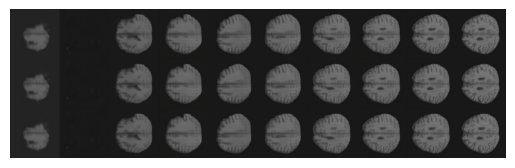

test 10: tensor([ 767,  652,  652,  652, 3093,  527, 3156, 3156,  527, 3563,  393, 3736,
        3736, 3993, 3993, 3245, 3736, 3908, 3993, 1105,  797, 2124, 2298,  324,
        1025, 3156, 3245, 3245, 3245,   20], device='cuda:0')
train10: tensor([ 767,  652,  652,  652, 3093,  527, 3156, 3156,  527, 3563,  393, 3736,
        3736, 3993, 3993, 3245, 3736, 3908, 3993, 1105,  797, 2124, 2298,  324,
        1025, 3156, 3245, 3245, 3245,   20], device='cuda:0')
gt   10: tensor([ 767,  652,  652,  652, 3093,  527, 3156, 3156,  527, 3563,  393, 3736,
        3736, 3993, 3993, 3245, 3736, 3908, 3993, 1105,  797, 2124, 2298,  324,
        1895, 3156, 3245, 3245, 3245,   20], device='cuda:0')
acc_train: 0.9911764705882353
acc_list: 0.3897058823529412
train_list: 0.39558823529411763


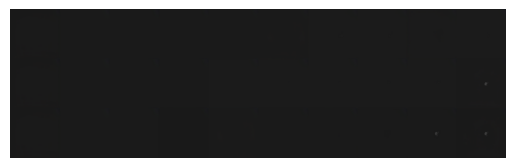

In [9]:


for idx, (inp_B3HW_low, inp_B3HW_super) in enumerate(ld_train):
    
    
    inp_B3HW_low = inp_B3HW_low.to(dist.get_device(), non_blocking=True)
    inp_B3HW_super = inp_B3HW_super.to(dist.get_device(), non_blocking=True)
    
    B, V = inp_B3HW_low.shape[0], vae.vocab_size
    gt_idx_Bl_low = vae.img_to_idxBl(inp_B3HW_low)
    gt_BL_low = torch.cat(gt_idx_Bl_low, dim=1)
    x_BLCv_wo_first_l_low = vae.quantize.embedding(gt_BL_low)  #这里应该是gt的idx组成的embedding
    
    
    gt_idx_Bl_super= vae.img_to_idxBl(inp_B3HW_super)
    gt_BL_super = torch.cat(gt_idx_Bl_super, dim=1)
    x_BLCv_wo_first_l_super= vae.quantize.idxBl_to_var_input(gt_idx_Bl_super)
    
    # [3,679,32]
    lowLen, lowC = x_BLCv_wo_first_l_low.shape[1], x_BLCv_wo_first_l_low.shape[2]
    
    lens = torch.tensor([lowLen] * B,dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device)  # 每个句子的 token 长度
    
    x_BLCv_wo_first_l_low = x_BLCv_wo_first_l_low.reshape( -1, lowC)
    
    max_seqlen_k = lens.max().to(device=x_BLCv_wo_first_l_super.device)  # 5
    cu_seqlens_k = torch.cumsum(torch.cat([torch.tensor([0],dtype=torch.int32).to(device=x_BLCv_wo_first_l_super.device), lens]), dim=0).to(device=x_BLCv_wo_first_l_super.device).to(dtype = torch.int32)
    label_B_or_BLT = (x_BLCv_wo_first_l_low, lens, cu_seqlens_k, max_seqlen_k)
    
    
    h_div_w = inp_B3HW_low.shape[-2] / inp_B3HW_low.shape[-1]
    T = 1 if inp_B3HW_low.dim() == 4 else inp_B3HW_low.shape[2]
    h_div_w_templates = np.array(list(dynamic_resolution_h_w.keys()))
    h_div_w_template = h_div_w_templates[np.argmin(np.abs(h_div_w-h_div_w_templates))]
    scale_schedule = dynamic_resolution_h_w[h_div_w_template]["1M"]['scales']
    scale_schedule = [ (min(t, T//4+1), h, w) for (t,h, w) in scale_schedule]
    
    
    idx_predict = []
    for si,pn in enumerate(patch_nums):
        idx_predict.append(torch.zeros(B,pn*pn,dtype=torch.int64).to(device=x_BLCv_wo_first_l_super.device))
    
    Cul_L = 0
    for si, pn in enumerate(patch_nums):
        num_pn = pn*pn
        temp_BLC = vae.quantize.idxBl_to_var_input(idx_predict)
        logits_BLV = srvar(label_B_or_BLT, temp_BLC ,scale_schedule,cfg_infer=True)
        idx_train = logits_BLV.data.argmax(dim=-1)
        
        idx_predict[si] = idx_train[:,Cul_L:Cul_L+num_pn].reshape(B,num_pn)
        Cul_L = Cul_L + num_pn
        
    idx_Bl_list = idx_predict
    idx_predict = torch.cat(idx_predict,dim=1)

    
    logits_BLV = srvar(label_B_or_BLT, x_BLCv_wo_first_l_super,scale_schedule,cfg_infer=True)
    idx_train = logits_BLV.data.argmax(dim=-1)

    show = 14+16
    print(f"test {idx}:",idx_predict[0][:show])
    #print(idx_Bl_list[0][0],idx_Bl_list[1][0],idx_Bl_list[2][0])
    print(f"train{idx}:",idx_train[0][:show])
    print(f"gt   {idx}:",gt_BL_super[0][:show])
    
    print("acc_train:",(idx_train == gt_BL_super).sum().item() / (B*gt_BL_super.shape[1]))
    print("acc_list:",(idx_predict == gt_BL_super).sum().item() / (B*gt_BL_super.shape[1]))
    print("train_list:",(idx_predict == idx_train).sum().item() / (B*gt_BL_super.shape[1]))


    nup_test = vae.idxBl_to_img(idx_Bl_list, same_shape=True, last_one=False)
    nup_gt = vae.idxBl_to_img(gt_idx_Bl_super, same_shape=True, last_one=False)
    start_idx = 0
    result_train = []
    for path_num in patch_nums:
        end_idx = start_idx + path_num ** 2
        result_train.append(idx_train[:, start_idx:end_idx])  
        start_idx = end_idx  
    nup_train = vae.idxBl_to_img(result_train, same_shape=True, last_one=False)
    
    def process_image(x):
        """处理单张图片"""    
        x = x[0].detach().cpu().permute(1, 2, 0).numpy()  # 转换为 HWC 格式的 numpy 数组
        x = (x * 0.5 + 0.5) * 255  # 反归一化并缩放到 [0, 255]
        x = x.astype(np.uint8)  # 转换为 uint8
        return x

    def concatenate_images(images, axis):
        """沿指定轴拼接图片"""
        return np.concatenate(images, axis=axis)
    
    train_combined = concatenate_images([process_image(x) for x in nup_train], axis=1)  # 左右连接
    test_combined = concatenate_images([process_image(x) for x in nup_test], axis=1)   # 左右连接
    gt_combined = concatenate_images([process_image(x) for x in nup_gt], axis=1)      # 左右连接

    # 将三个结果上下连接
    final_image = concatenate_images([test_combined, train_combined , gt_combined], axis=0)  # 上下连接
    # Image.fromarray(final_image)
    plt.imshow(final_image)
    plt.axis('off')  # 可选，关闭坐标轴
    plt.show()
    if tot > 0 and idx >= tot:
        break